In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

DATA_PATH = 'chicago_crime_dataset.csv'

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 120,759  |  Columns: 23


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,_year
0,13733090,JJ130321,01/28/2025 03:30:00 PM,076XX S RACINE AVE,0560,ASSAULT,SIMPLE,STREET,False,False,612,6,17.0,71.0,08A,1169643.0,1854247.0,2025,05/17/2025 03:40:52 PM,41.755554,-87.653868,"(41.755554244, -87.653867946)",2025
1,13909076,JJ344224,07/22/2025 12:40:00 PM,011XX W THORNDALE AVE,0560,ASSAULT,SIMPLE,TAVERN / LIQUOR STORE,True,False,2433,24,48.0,77.0,08A,1167566.0,1939682.0,2025,03/14/2026 03:41:39 PM,41.990039,-87.659020,"(41.990039445, -87.659019968)",2025
2,13101860,JG295014,06/09/2023 08:23:00 PM,008XX S KOLMAR AVE,1507,PROSTITUTION,SOLICIT OFF PUBLIC WAY,STREET,True,False,1131,11,24.0,26.0,16,1146144.0,1895827.0,2023,08/19/2023 03:40:26 PM,41.870133,-87.738933,"(41.870133029, -87.738933006)",2023
3,13701134,JH553823,12/24/2024 05:38:00 AM,043XX N KIMBALL AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,CONVENIENCE STORE,False,False,1723,17,33.0,16.0,07,1152935.0,1928827.0,2024,11/02/2025 03:41:09 PM,41.960556,-87.713125,"(41.96055619, -87.71312483)",2024
4,13967696,JJ415709,09/15/2025 03:20:00 PM,004XX S WESTERN AVE,0312,ROBBERY,ARMED - KNIFE / CUTTING INSTRUMENT,CTA TRAIN,True,False,1135,11,28.0,28.0,03,1160478.0,1897788.0,2025,03/14/2026 03:41:39 PM,41.875230,-87.686254,"(41.875229772, -87.686253982)",2025


In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
print("\nUnparseable dates:", df['Date'].isna().sum())
print(f"Date range: {df['Date'].min()}  ->  {df['Date'].max()}")
print(f"Years covered: {sorted(df['Year'].unique())}")


Unparseable dates: 0
Date range: 2021-01-01 00:00:00  ->  2025-12-31 23:58:00
Years covered: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_report

,missing_count,missing_pct
X Coordinate,1877,1.55
Y Coordinate,1877,1.55
Latitude,1877,1.55
Longitude,1877,1.55
Location,1877,1.55
Location Description,463,0.38
Community Area,11,0.01


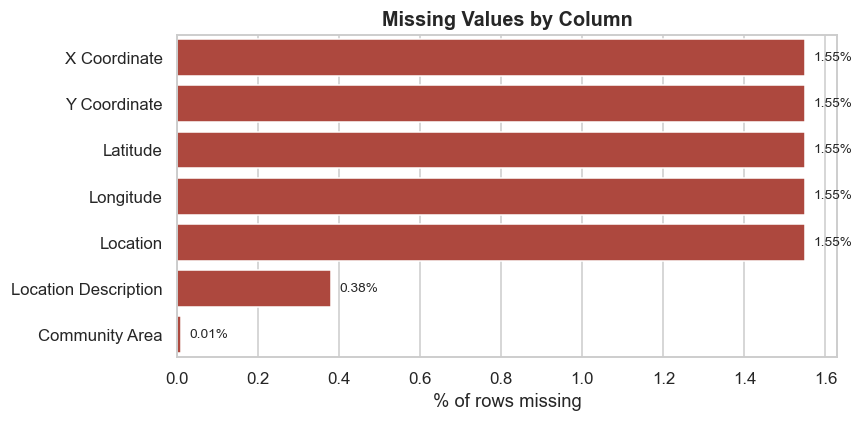

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing_report['missing_pct'], y=missing_report.index, ax=ax, color='#c0392b')
for i, v in enumerate(missing_report['missing_pct']):
    ax.text(v + 0.02, i, f"{v}%", va='center', fontsize=9)
ax.set_xlabel('% of rows missing')
ax.set_ylabel('')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

In [7]:
df['Location Description'] = df['Location Description'].fillna('UNKNOWN')
geo_missing_together = df[['X Coordinate','Y Coordinate','Latitude','Longitude']].isnull().all(axis=1).sum()
geo_missing_any = df[['X Coordinate','Y Coordinate','Latitude','Longitude']].isnull().any(axis=1).sum()
print(f"Rows missing ALL geo fields: {geo_missing_together} | missing ANY geo field: {geo_missing_any}")
# Flag for downstream geospatial cells to filter on
df['has_geo'] = df[['Latitude', 'Longitude']].notnull().all(axis=1)

Rows missing ALL geo fields: 1877 | missing ANY geo field: 1877


In [8]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated ID values:", df['ID'].duplicated().sum())
print("Duplicated Case Number values:", df['Case Number'].duplicated().sum())
valid_lat = df['Latitude'].between(41.6, 42.05)
valid_lon = df['Longitude'].between(-87.95, -87.5)
invalid_coords = df[df['has_geo'] & ~(valid_lat & valid_lon)]
print(f"Geocoded rows falling outside Chicago's bounding box: {len(invalid_coords)}")

Fully duplicated rows: 0
Duplicated ID values: 0
Duplicated Case Number values: 4
Geocoded rows falling outside Chicago's bounding box: 0


In [9]:
df['minute'] = df['Date'].dt.minute
df['second'] = df['Date'].dt.second
on_the_hour_pct = ((df['minute'] == 0) & (df['second'] == 0)).mean() * 100
midnight_pct = (df['Date'].dt.time == pd.Timestamp('00:00:00').time()).mean() * 100
print(f"Records with an exact on-the-hour timestamp (minute=0, second=0): {on_the_hour_pct:.1f}%")
print(f"Records logged at exactly 00:00:00 (midnight): {midnight_pct:.1f}%")
print("\n-> A high on-the-hour share signals rounded/estimated report times.")
print("-> Treat the 'Hour of Day' distribution as directionally correct, not minute-precise.")

Records with an exact on-the-hour timestamp (minute=0, second=0): 28.9%
Records logged at exactly 00:00:00 (midnight): 3.4%

-> A high on-the-hour share signals rounded/estimated report times.
-> Treat the 'Hour of Day' distribution as directionally correct, not minute-precise.


In [10]:
numeric_cols = ['Beat', 'District', 'Ward', 'Community Area', 'Latitude', 'Longitude']
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Beat,120759.0,1151.098634,704.389546,111.000000,533.000000,1033.000000,1723.000000,2535.000000
District,120759.0,11.281039,7.038287,1.000000,5.000000,10.000000,17.000000,31.000000
Ward,120759.0,23.322262,13.848473,1.000000,10.000000,24.000000,34.000000,50.000000
Community Area,120748.0,36.457730,21.456534,1.000000,23.000000,32.000000,53.000000,77.000000
Latitude,118882.0,41.845761,0.086536,41.644604,41.771113,41.865016,41.907369,42.022537
Longitude,118882.0,-87.669844,0.059751,-87.939733,-87.712334,-87.662582,-87.627271,-87.524616


In [11]:
cat_cols = ['Primary Type', 'Location Description', 'District', 'Domestic', 'Arrest']
for c in cat_cols:
    print(f"\n--- {c} : top values ---")
    print(df[c].value_counts(dropna=False).head(8))


--- Primary Type : top values ---
Primary Type
THEFT                  23660
BATTERY                22338
CRIMINAL DAMAGE        11330
ASSAULT                10341
OTHER OFFENSE           8201
MOTOR VEHICLE THEFT     8112
WEAPONS VIOLATION       7394
DECEPTIVE PRACTICE      6992
Name: count, dtype: int64

--- Location Description : top values ---
Location Description
STREET                                    33558
APARTMENT                                 21907
RESIDENCE                                 13989
SIDEWALK                                   7798
SMALL RETAIL STORE                         4070
PARKING LOT / GARAGE (NON RESIDENTIAL)     3902
ALLEY                                      3105
DEPARTMENT STORE                           2701
Name: count, dtype: int64

--- District : top values ---
District
11    8192
8     7509
6     7169
1     6910
12    6625
4     6518
25    6350
18    6268
Name: count, dtype: int64

--- Domestic : top values ---
Domestic
False    97408
True     23

C:\Users\admin\AppData\Local\Temp\ipykernel_3164\487421458.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=top_crimes.values, y=top_crimes.index, ax=ax, palette='mako')


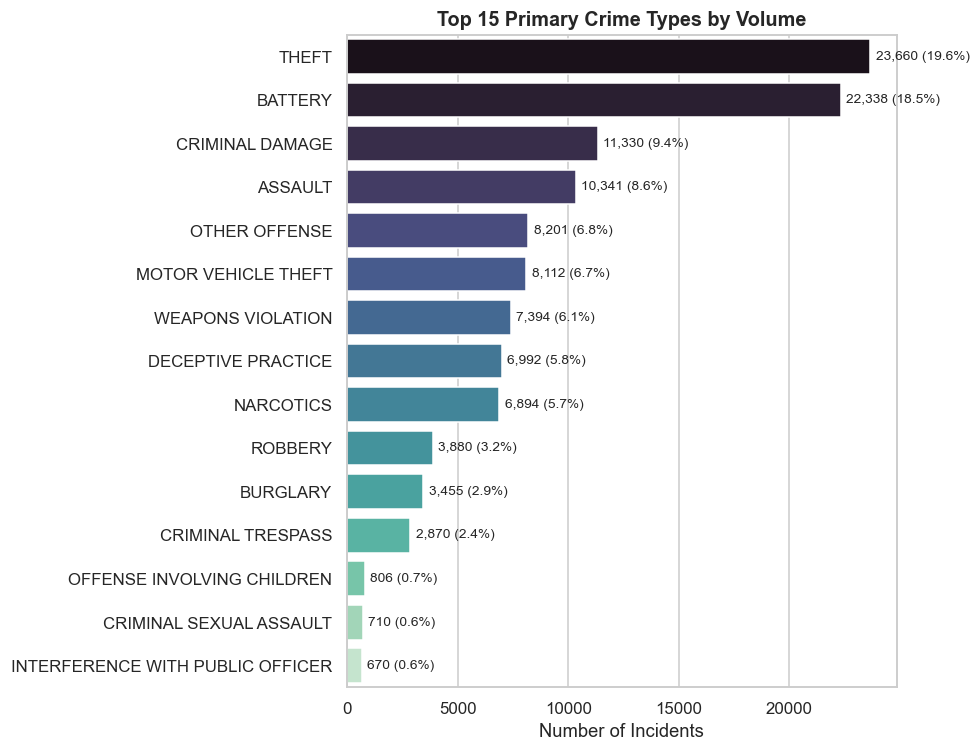

These 15 types account for 97.6% of all recorded incidents.


In [12]:
top_crimes = df['Primary Type'].value_counts().head(15)
top_crimes_pct = (top_crimes / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 7))
bars = sns.barplot(x=top_crimes.values, y=top_crimes.index, ax=ax, palette='mako')
for i, (val, pct) in enumerate(zip(top_crimes.values, top_crimes_pct.values)):
    ax.text(val + max(top_crimes.values)*0.01, i, f"{val:,} ({pct}%)", va='center', fontsize=9)
ax.set_xlabel('Number of Incidents')
ax.set_ylabel('')
ax.set_title('Top 15 Primary Crime Types by Volume')
plt.tight_layout()
plt.show()

print(f"These 15 types account for {top_crimes_pct.sum():.1f}% of all recorded incidents.")

Citywide arrest rate:            32.81%
Domestic-flagged incident share: 19.34%


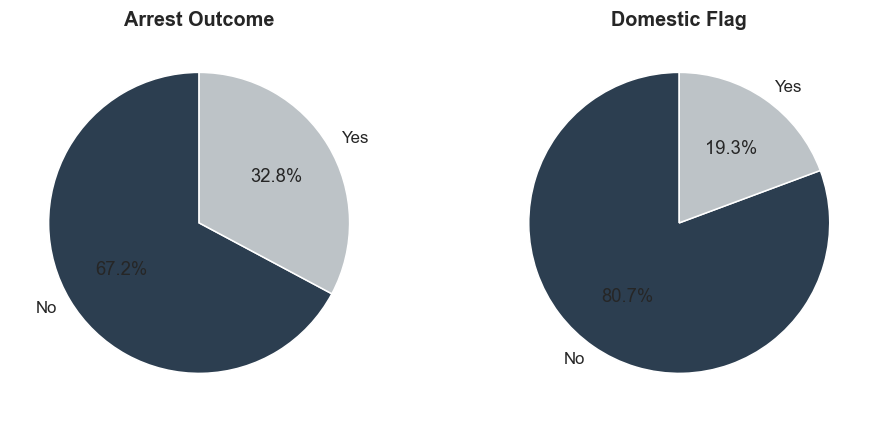

In [13]:
arrest_rate = df['Arrest'].mean() * 100
domestic_rate = df['Domestic'].mean() * 100
print(f"Citywide arrest rate:            {arrest_rate:.2f}%")
print(f"Domestic-flagged incident share: {domestic_rate:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, col, rate, title in zip(
    axes, ['Arrest', 'Domestic'], [arrest_rate, domestic_rate],
    ['Arrest Outcome', 'Domestic Flag']
):
    counts = df[col].value_counts()
    ax.pie(counts, labels=[f"{'Yes' if i else 'No'}" for i in counts.index],
           autopct='%1.1f%%', startangle=90, colors=['#2c3e50', '#bdc3c7'])
    ax.set_title(title)
plt.tight_layout()
plt.show()


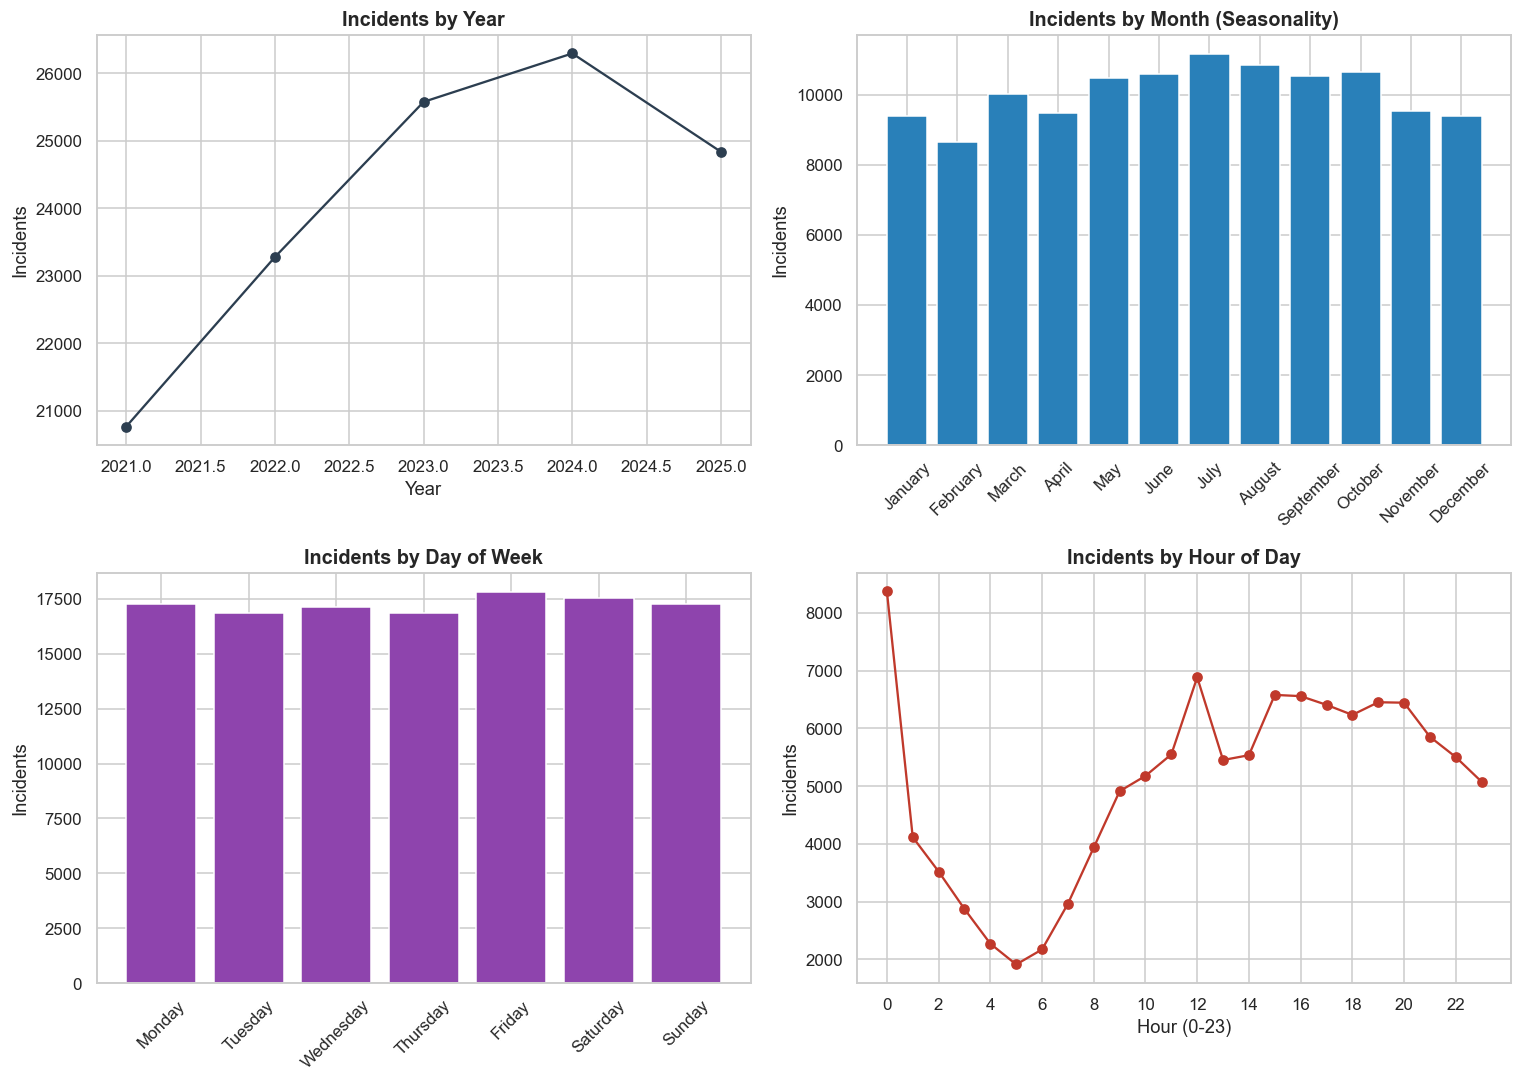

In [14]:
df['year_n'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['month_name'] = df['Date'].dt.month_name()
df['day_of_week'] = df['Date'].dt.day_name()
df['hour'] = df['Date'].dt.hour

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By year
yearly = df['year_n'].value_counts().sort_index()
axes[0,0].plot(yearly.index, yearly.values, marker='o', color='#2c3e50')
axes[0,0].set_title('Incidents by Year')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Incidents')

# By month (seasonality)
monthly = df['month_name'].value_counts().reindex(month_order)
axes[0,1].bar(monthly.index, monthly.values, color='#2980b9')
axes[0,1].set_title('Incidents by Month (Seasonality)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylabel('Incidents')

# By day of week
dow = df['day_of_week'].value_counts().reindex(dow_order)
axes[1,0].bar(dow.index, dow.values, color='#8e44ad')
axes[1,0].set_title('Incidents by Day of Week')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylabel('Incidents')

# By hour
hourly = df['hour'].value_counts().sort_index()
axes[1,1].plot(hourly.index, hourly.values, marker='o', color='#c0392b')
axes[1,1].set_title('Incidents by Hour of Day')
axes[1,1].set_xlabel('Hour (0-23)'); axes[1,1].set_ylabel('Incidents')
axes[1,1].set_xticks(range(0,24,2))

plt.tight_layout()
plt.show()

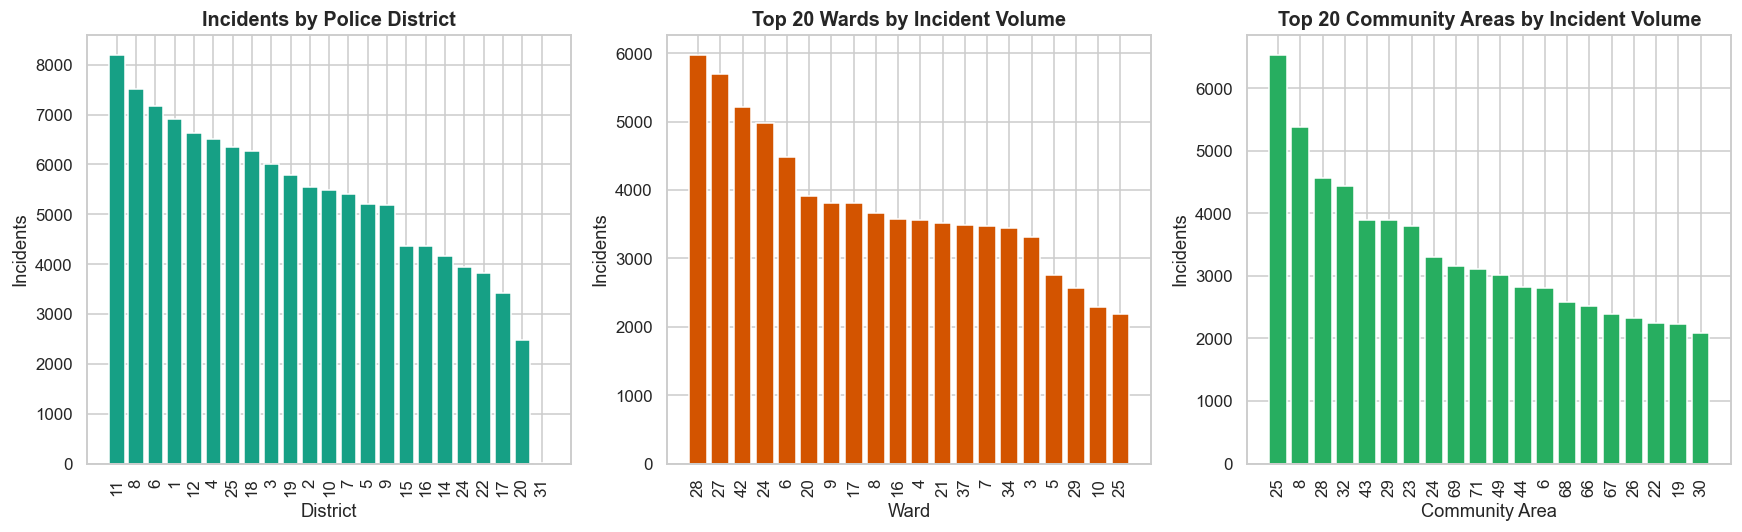

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

district_counts = df['District'].value_counts().sort_values(ascending=False)
axes[0].bar(district_counts.index.astype(str), district_counts.values, color='#16a085')
axes[0].set_title('Incidents by Police District')
axes[0].set_xlabel('District'); axes[0].set_ylabel('Incidents')
axes[0].tick_params(axis='x', rotation=90)

ward_counts = df['Ward'].value_counts().sort_values(ascending=False).head(20)
axes[1].bar(ward_counts.index.astype(int).astype(str), ward_counts.values, color='#d35400')
axes[1].set_title('Top 20 Wards by Incident Volume')
axes[1].set_xlabel('Ward'); axes[1].set_ylabel('Incidents')
axes[1].tick_params(axis='x', rotation=90)

ca_counts = df['Community Area'].value_counts().sort_values(ascending=False).head(20)
axes[2].bar(ca_counts.index.astype(int).astype(str), ca_counts.values, color='#27ae60')
axes[2].set_title('Top 20 Community Areas by Incident Volume')
axes[2].set_xlabel('Community Area'); axes[2].set_ylabel('Incidents')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

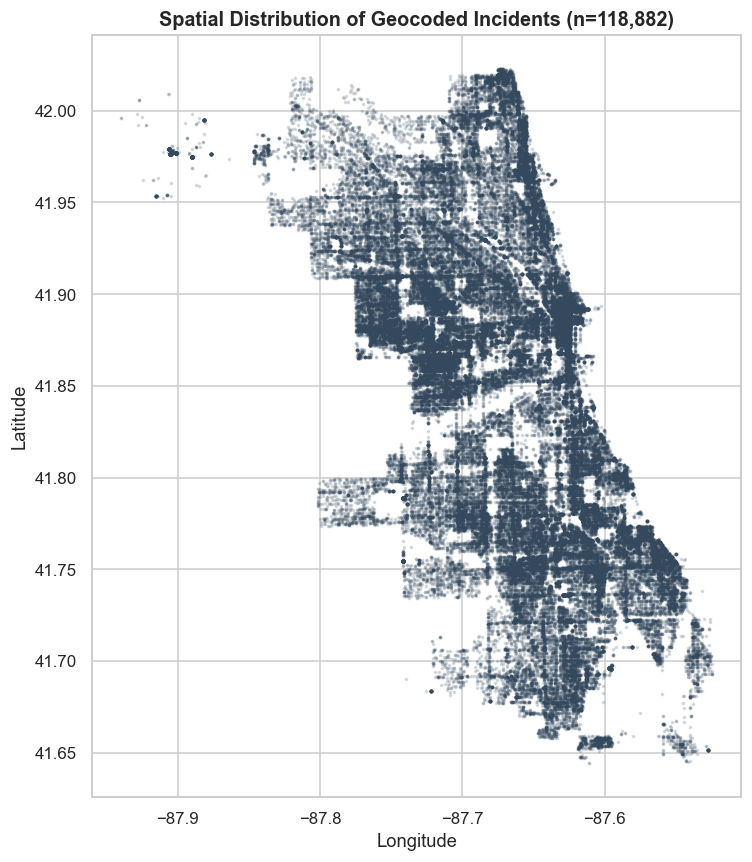

In [16]:
geo_df = df[df['has_geo']]
fig, ax = plt.subplots(figsize=(7, 8))
sc = ax.scatter(geo_df['Longitude'], geo_df['Latitude'], s=2, alpha=0.15, c='#34495e')
ax.set_title(f'Spatial Distribution of Geocoded Incidents (n={len(geo_df):,})')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_3164\3467338658.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_arrest['arrest_rate'], y=crime_arrest.index, palette=colors, ax=ax)


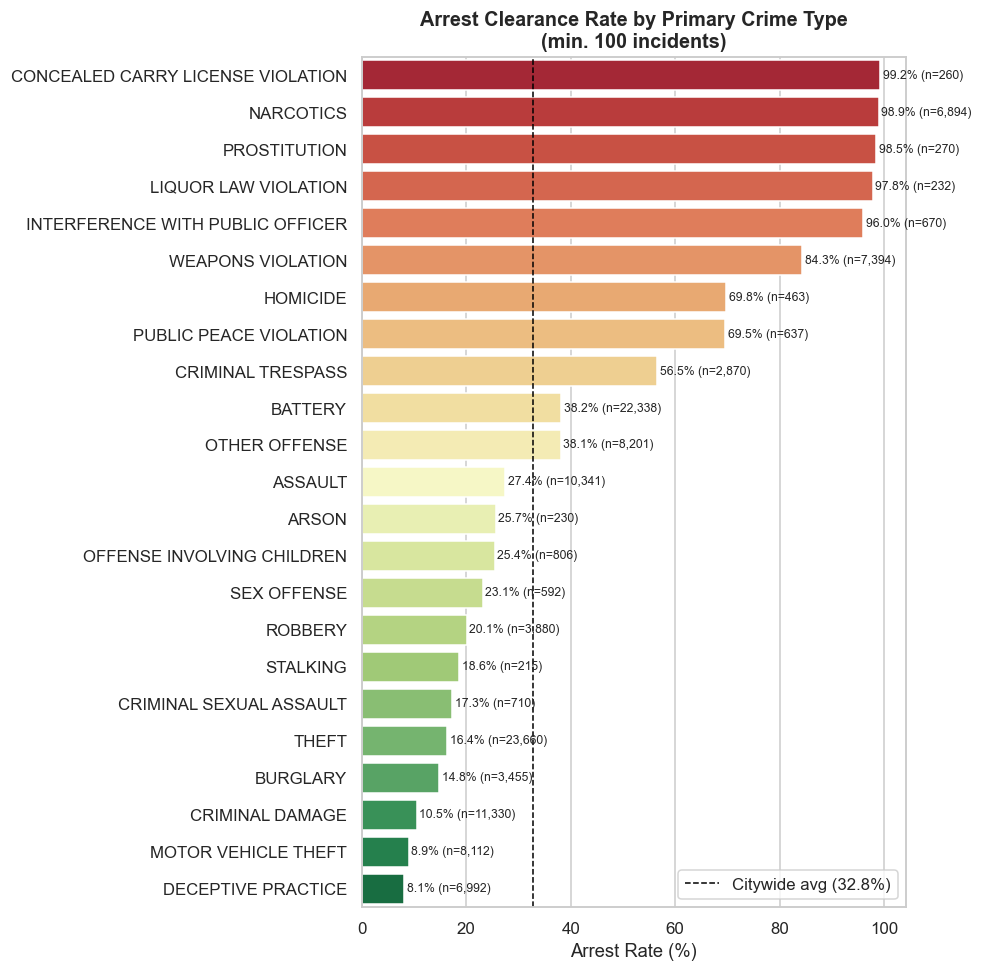

Proactive/possession-driven offenses (e.g. narcotics, weapons) cluster at the high end
because the arrest often IS the incident. Reactive property crimes (theft, burglary,
motor vehicle theft) cluster at the low end because they're typically reported after the fact.


In [17]:
crime_arrest = (
    df.groupby('Primary Type')['Arrest']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'arrest_rate', 'count': 'total_incidents'})
)
crime_arrest['arrest_rate'] *= 100
crime_arrest = crime_arrest[crime_arrest['total_incidents'] >= 100].sort_values('arrest_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
colors = sns.color_palette('RdYlGn', len(crime_arrest))
sns.barplot(x=crime_arrest['arrest_rate'], y=crime_arrest.index, palette=colors, ax=ax)
for i, (rate, n) in enumerate(zip(crime_arrest['arrest_rate'], crime_arrest['total_incidents'])):
    ax.text(rate + 0.5, i, f"{rate:.1f}% (n={n:,})", va='center', fontsize=8)
ax.axvline(arrest_rate, color='black', linestyle='--', linewidth=1, label=f'Citywide avg ({arrest_rate:.1f}%)')
ax.set_xlabel('Arrest Rate (%)'); ax.set_ylabel('')
ax.set_title('Arrest Clearance Rate by Primary Crime Type\n(min. 100 incidents)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("Proactive/possession-driven offenses (e.g. narcotics, weapons) cluster at the high end")
print("because the arrest often IS the incident. Reactive property crimes (theft, burglary,")
print("motor vehicle theft) cluster at the low end because they're typically reported after the fact.")

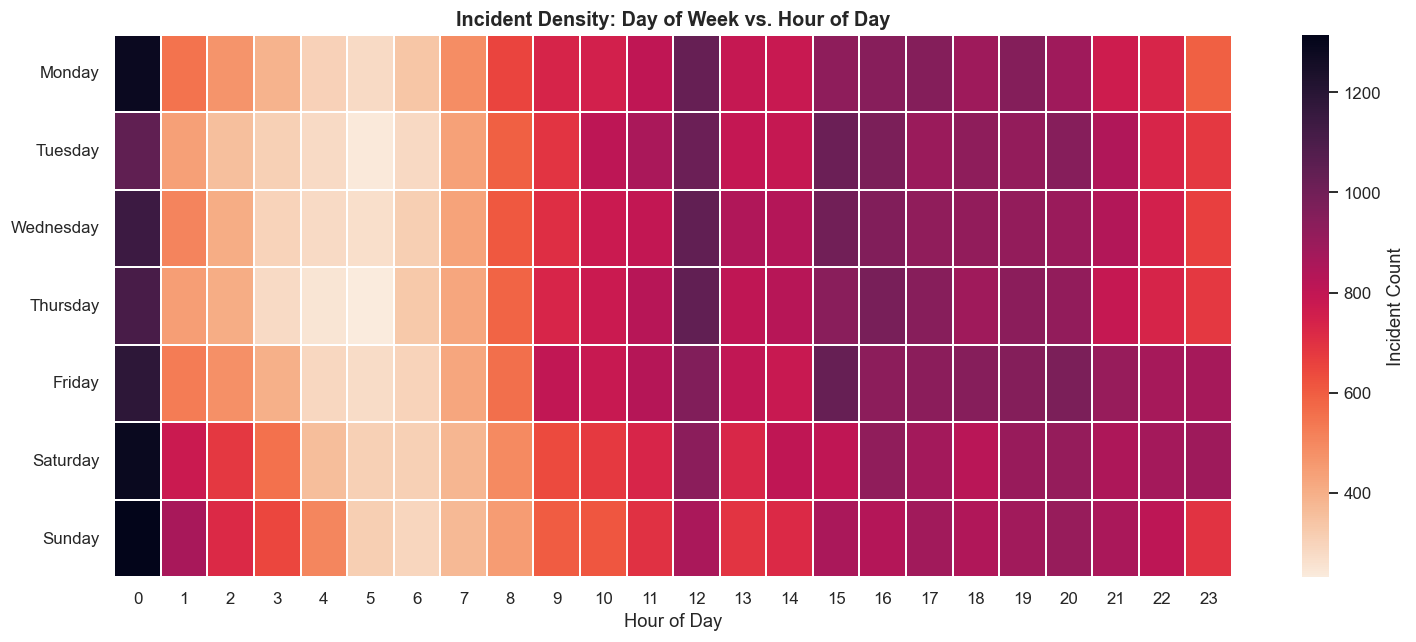

In [18]:
heatmap_data = df.pivot_table(index='day_of_week', columns='hour', values='ID', aggfunc='count')
heatmap_data = heatmap_data.reindex(dow_order)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='rocket_r', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Incident Count'}, ax=ax)
ax.set_title('Incident Density: Day of Week vs. Hour of Day')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_3164\3898995342.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_domestic['domestic_rate'], y=loc_domestic.index, palette='flare', ax=ax)


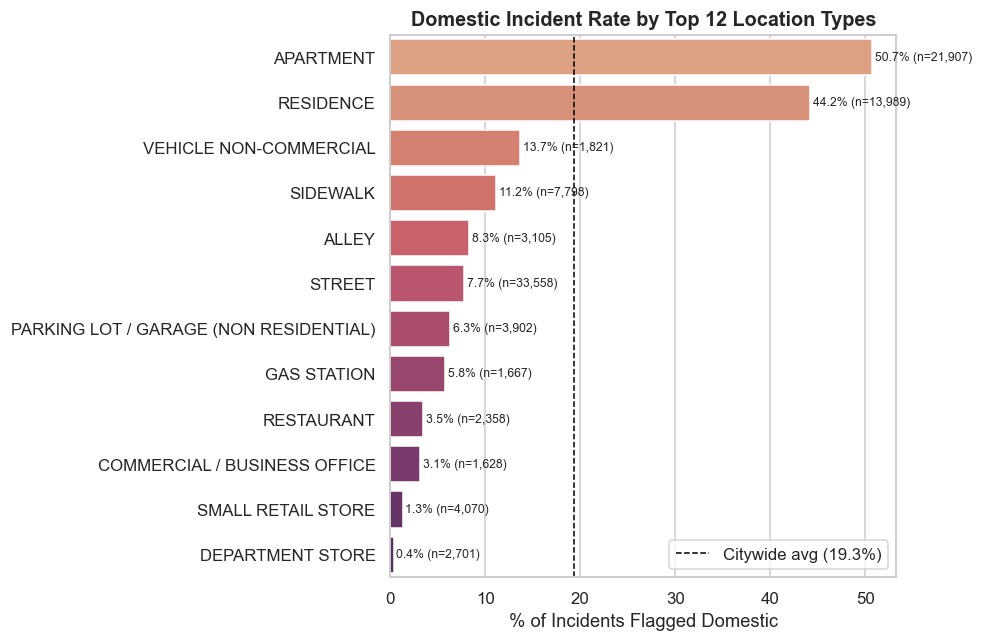

In [19]:
top_locations = df['Location Description'].value_counts().head(12).index
loc_domestic = (
    df[df['Location Description'].isin(top_locations)]
    .groupby('Location Description')['Domestic']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'domestic_rate', 'count': 'total_incidents'})
    .sort_values('domestic_rate', ascending=False)
)
loc_domestic['domestic_rate'] *= 100

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=loc_domestic['domestic_rate'], y=loc_domestic.index, palette='flare', ax=ax)
for i, (rate, n) in enumerate(zip(loc_domestic['domestic_rate'], loc_domestic['total_incidents'])):
    ax.text(rate + 0.3, i, f"{rate:.1f}% (n={n:,})", va='center', fontsize=8)
ax.axvline(domestic_rate, color='black', linestyle='--', linewidth=1, label=f'Citywide avg ({domestic_rate:.1f}%)')
ax.set_xlabel('% of Incidents Flagged Domestic'); ax.set_ylabel('')
ax.set_title('Domestic Incident Rate by Top 12 Location Types')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

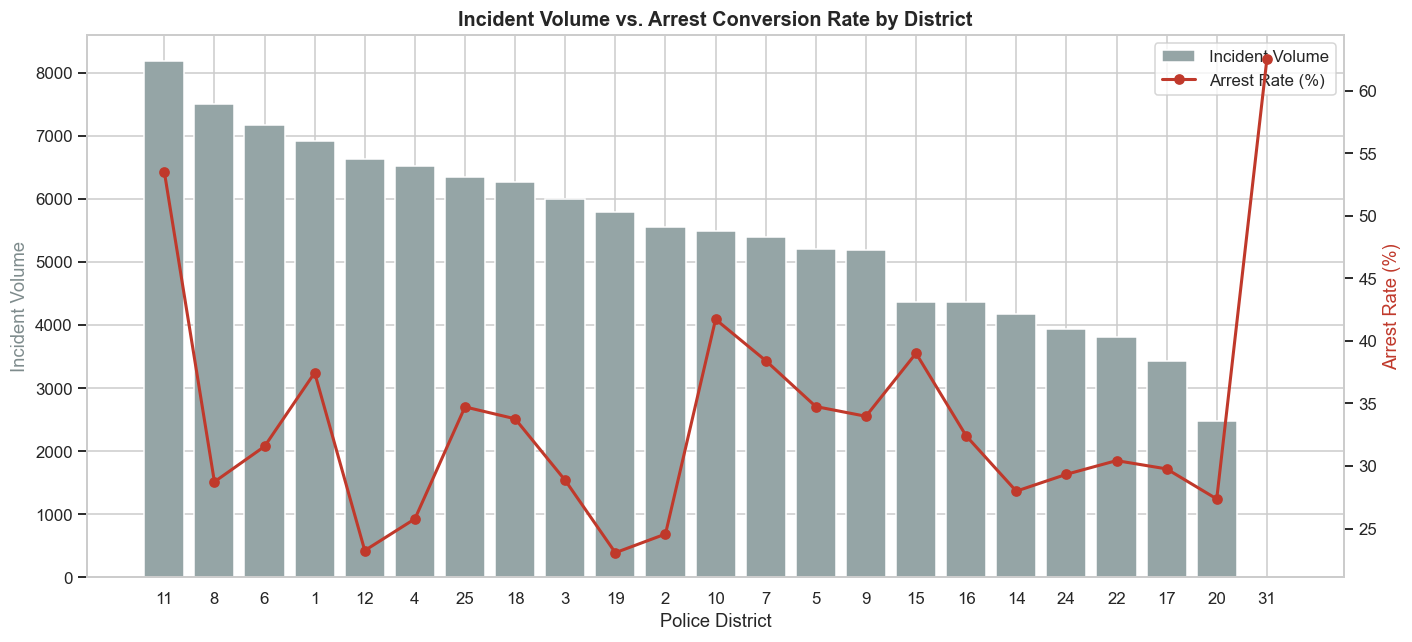

Districts with high volume but a below-average arrest rate line are the clearest
evidence of enforcement-capacity strain relative to case load.


In [20]:
district_stats = (
    df.groupby('District')['Arrest']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'arrest_rate', 'count': 'total_incidents'})
)
district_stats['arrest_rate'] *= 100
district_stats = district_stats.sort_values('total_incidents', ascending=False)

fig, ax1 = plt.subplots(figsize=(13, 6))
x = np.arange(len(district_stats))
ax1.bar(x, district_stats['total_incidents'], color='#95a5a6', label='Incident Volume')
ax1.set_xlabel('Police District'); ax1.set_ylabel('Incident Volume', color='#7f8c8d')
ax1.set_xticks(x); ax1.set_xticklabels(district_stats.index.astype(int).astype(str))

ax2 = ax1.twinx()
ax2.plot(x, district_stats['arrest_rate'], color='#c0392b', marker='o', linewidth=2, label='Arrest Rate (%)')
ax2.set_ylabel('Arrest Rate (%)', color='#c0392b')
ax2.grid(False)

ax1.set_title('Incident Volume vs. Arrest Conversion Rate by District')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

print("Districts with high volume but a below-average arrest rate line are the clearest")
print("evidence of enforcement-capacity strain relative to case load.")

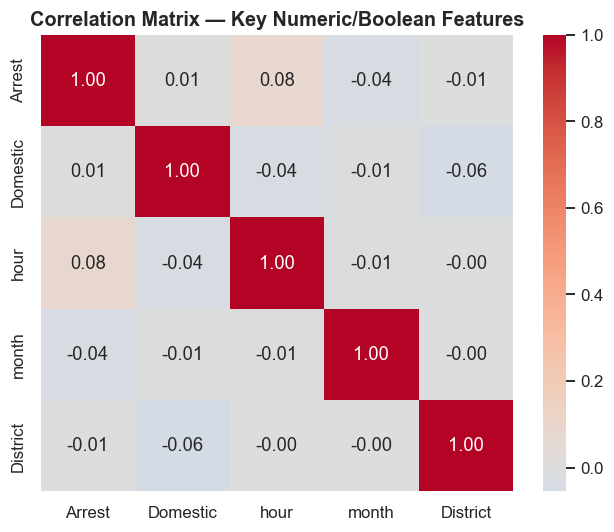

Note: correlations here are weak by nature (categorical drivers dominate this dataset);
the groupby-based comparisons above are the primary analytical evidence, not this matrix.


In [21]:
corr_df = df[['Arrest', 'Domestic', 'hour', 'month', 'District']].copy()
corr_df['Arrest'] = corr_df['Arrest'].astype(int)
corr_df['Domestic'] = corr_df['Domestic'].astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Key Numeric/Boolean Features')
plt.tight_layout()
plt.show()

print("Note: correlations here are weak by nature (categorical drivers dominate this dataset);")
print("the groupby-based comparisons above are the primary analytical evidence, not this matrix.")

In [22]:
top1_crime = top_crimes.index[0]
top1_pct = top_crimes_pct.iloc[0]
lowest_arrest_crime = crime_arrest['arrest_rate'].idxmin()
highest_arrest_crime = crime_arrest['arrest_rate'].idxmax()
busiest_hour = int(hourly.idxmax())
busiest_dow = dow.idxmax()
busiest_district = int(district_stats['total_incidents'].idxmax())
weakest_district_row = district_stats[district_stats['total_incidents'] > district_stats['total_incidents'].median()].sort_values('arrest_rate').iloc[0]

print("SUMMARY INPUTS FOR THE INSIGHTS BELOW")
print("-"*50)
print(f"Top crime type:            {top1_crime} ({top1_pct}% of all incidents)")
print(f"Lowest-arrest crime type:  {lowest_arrest_crime} ({crime_arrest.loc[lowest_arrest_crime,'arrest_rate']:.1f}%)")
print(f"Highest-arrest crime type: {highest_arrest_crime} ({crime_arrest.loc[highest_arrest_crime,'arrest_rate']:.1f}%)")
print(f"Busiest hour:              {busiest_hour}:00")
print(f"Busiest day of week:       {busiest_dow}")
print(f"Highest-volume district:   {busiest_district}")
print(f"Above-median-volume district with weakest arrest rate: District {int(weakest_district_row.name)} "
      f"({weakest_district_row['arrest_rate']:.1f}% vs. citywide {arrest_rate:.1f}%)")

SUMMARY INPUTS FOR THE INSIGHTS BELOW
--------------------------------------------------
Top crime type:            THEFT (19.6% of all incidents)
Lowest-arrest crime type:  DECEPTIVE PRACTICE (8.1%)
Highest-arrest crime type: CONCEALED CARRY LICENSE VIOLATION (99.2%)
Busiest hour:              0:00
Busiest day of week:       Friday
Highest-volume district:   11
Above-median-volume district with weakest arrest rate: District 19 (23.1% vs. citywide 32.8%)
